In [60]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as mp
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score,roc_curve, ConfusionMatrixDisplay)

In [61]:
sb.set_style("whitegrid")
mp.rcParams["figure.figsize"]=(10,6)

In [62]:
address="insurance_claims.csv"
df=pd.read_csv(address)
print("Shape:",df.shape)
print("Columns:",df.columns.tolist())
df.head(5)

Shape: (1000, 40)
Columns: ['months_as_customer', 'age', 'policy_number', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported', '_c39']


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,17 10 2014,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,27 06 2006,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,6 09 2000,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,25 05 1990,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,6 06 2014,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [63]:
print(df.info())
print("\nMissing Values:\n",df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

fraud_reported
N    753
Y    247
Name: count, dtype: int64
1000


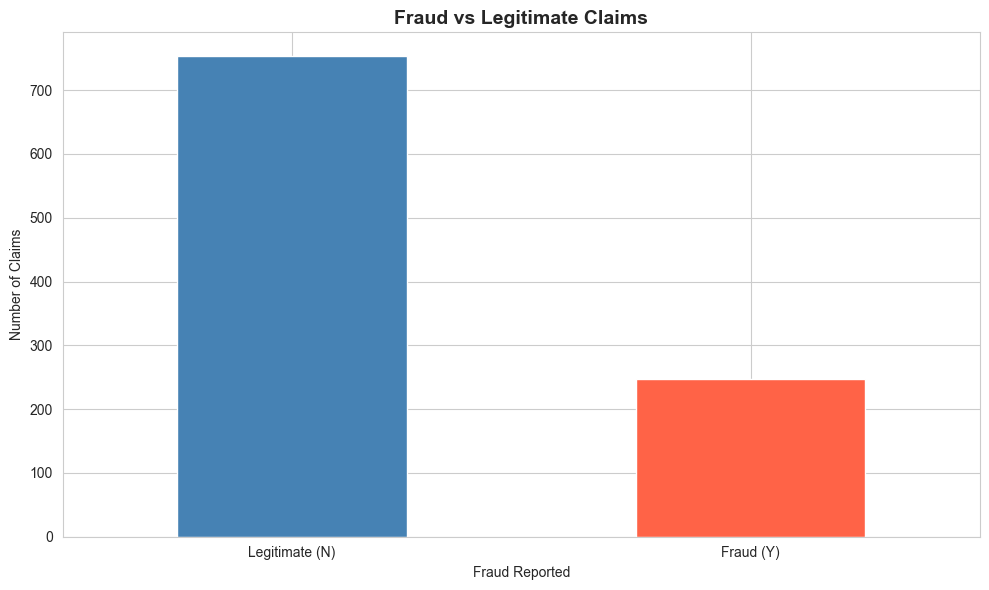

In [64]:
fraudCount=df["fraud_reported"].value_counts() #to check if the target variable is balanced
print(fraudCount)
print(fraudCount.sum())

fig, ax = mp.subplots()
fraudCount.plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_title('Fraud vs Legitimate Claims', fontsize=14, fontweight='bold')
ax.set_xlabel('Fraud Reported')
ax.set_ylabel('Number of Claims')
ax.set_xticklabels(['Legitimate (N)', 'Fraud (Y)'], rotation=0)
mp.tight_layout()
mp.savefig('fraud_balance.png', dpi=150)   # Save for your website
mp.show()

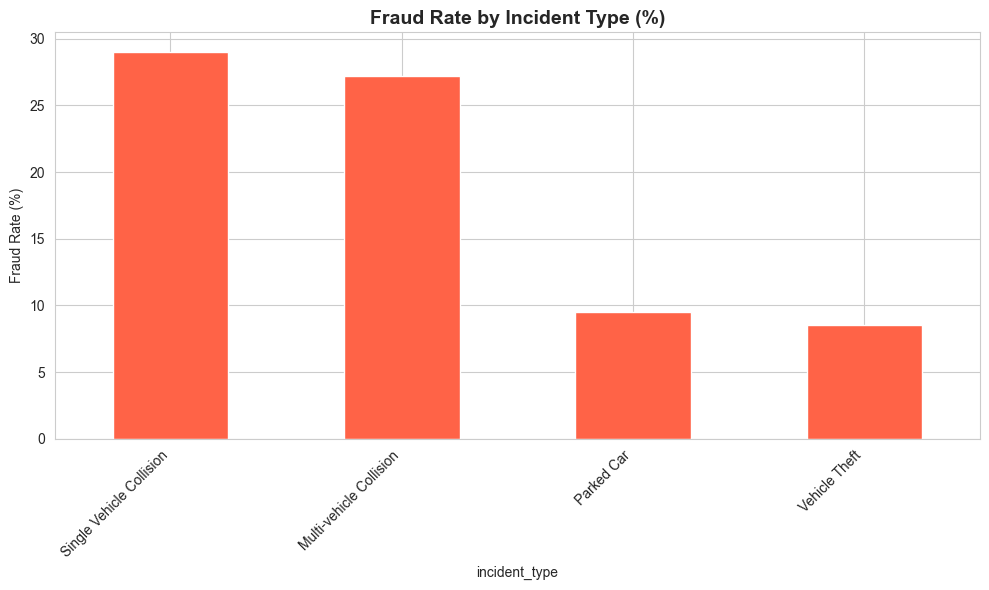

In [65]:
#Fraud rate by incident type
fraud_by_incident = df.groupby('incident_type')['fraud_reported'].apply(lambda x: (x == 'Y').mean() * 100).sort_values(ascending=False)

fraud_by_incident.plot(kind='bar', color='tomato')
mp.title('Fraud Rate by Incident Type (%)', fontsize=14, fontweight='bold')
mp.ylabel('Fraud Rate (%)')
mp.xticks(rotation=45, ha='right')
mp.tight_layout()
mp.savefig('fraud_by_incident.png', dpi=150)
mp.show()

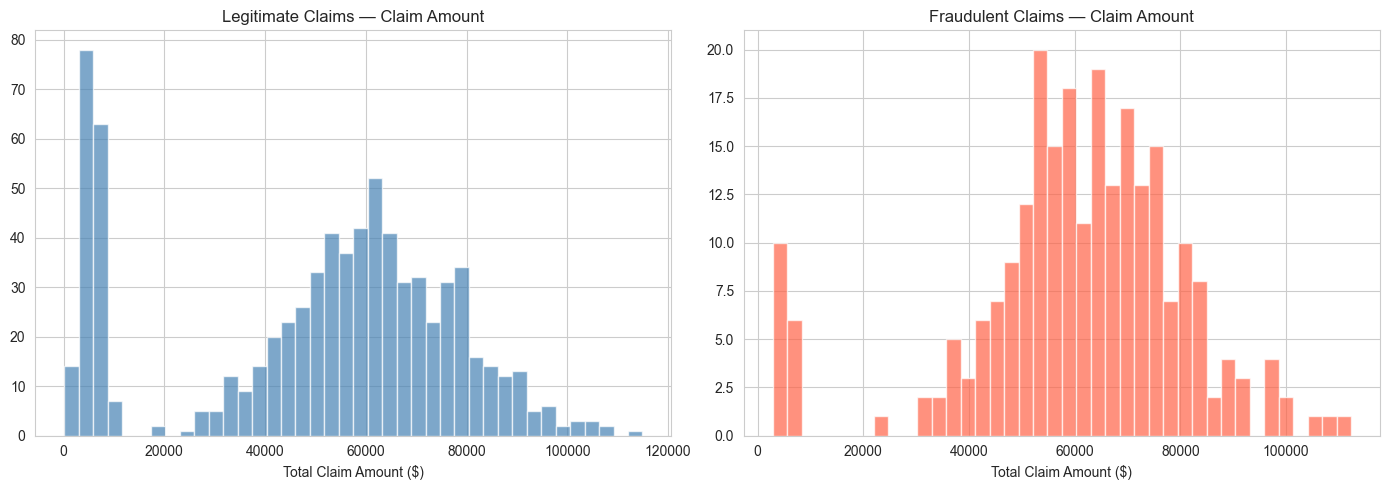

In [66]:
#Distribution of claim amounts, to check if fraudulent claims tend to be large, this can be used as a signal
fig, axes = mp.subplots(1, 2, figsize=(14, 5))

df[df['fraud_reported']=='N']['total_claim_amount'].hist( bins=40, ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Legitimate Claims — Claim Amount')
axes[0].set_xlabel('Total Claim Amount ($)')

df[df['fraud_reported']=='Y']['total_claim_amount'].hist(bins=40, ax=axes[1], color='tomato', alpha=0.7)
axes[1].set_title('Fraudulent Claims — Claim Amount')
axes[1].set_xlabel('Total Claim Amount ($)')

mp.tight_layout()
mp.savefig('claim_amount_distribution.png', dpi=150)
mp.show()

In [67]:
##Data Cleaning and Preprocessing
# Dropping columns that are useless
# 'policy_number' is just an ID — not a pattern
# '_c39' is usually an empty junk column in this dataset

cols_to_drop = ['policy_number', 'policy_bind_date', 'incident_date','insured_zip', '_c39'] #list of all useless columns
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])


df = df.replace('?', np.nan) #Replacing '?' with NaN (as this dataset uses ? for missing)


df = df.dropna(thresh=len(df.columns) * 0.6)  #Dropping rows with too many missing values, Keep rows with 60%+ data


for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0]) #Filling the remaining missing data with mode (values with the highest frequency)

df.head(5)

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,OH,250/500,1000,1406.91,0,MALE,MD,craft-repair,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,IN,250/500,2000,1197.22,5000000,MALE,MD,machine-op-inspct,...,0,NO,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,OH,100/300,2000,1413.14,5000000,FEMALE,PhD,sales,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,IL,250/500,2000,1415.74,6000000,FEMALE,PhD,armed-forces,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,IL,500/1000,1000,1583.91,6000000,MALE,Associate,sales,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [68]:
##Encoding the categorical variables
df['fraud_reported'] = df['fraud_reported'].map({'Y': 1, 'N': 0}) # Encoding the target variable first

# Encode all remaining text columns using LabelEncoder
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# print(df.dtypes.value_counts())
df.head(5)

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,2,1,1000,1406.91,0,1,4,2,...,2,1,71610,6510,13020,52080,10,1,2004,1
1,228,42,1,1,2000,1197.22,5000000,1,4,6,...,0,0,5070,780,780,3510,8,12,2007,1
2,134,29,2,0,2000,1413.14,5000000,0,6,11,...,3,0,34650,7700,3850,23100,4,30,2007,0
3,256,41,0,1,2000,1415.74,6000000,0,6,1,...,2,0,63400,6340,6340,50720,3,34,2014,1
4,228,44,0,2,1000,1583.91,6000000,1,0,11,...,1,0,6500,1300,650,4550,0,31,2009,0


In [69]:
## Splitting between feature and target
X=df.drop("fraud_reported",axis=1) #Drops the target column
Y=df["fraud_reported"]
# Y
# X

In [70]:
##Fixing Class Imbalance with SMOTE

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y) # stratify=y means both splits keep the same fraud ratio

smote = SMOTE(random_state=42)
X_train_sm, Y_train_sm = smote.fit_resample(X_train, Y_train) # Apply SMOTE only to training data

In [71]:
##Training the models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_sm, Y_train_sm)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model":  model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "auc":    roc_auc_score(Y_test, y_prob)
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(Y_test, y_pred, target_names=['Legitimate','Fraud']))
    print(f"  ROC-AUC Score: {results[name]['auc']:.4f}")

C:\Users\Ebenezer Afonja\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.81      0.49      0.61       151
       Fraud       0.29      0.65      0.41        49

    accuracy                           0.53       200
   macro avg       0.55      0.57      0.51       200
weighted avg       0.69      0.53      0.56       200

  ROC-AUC Score: 0.6026

  Random Forest
              precision    recall  f1-score   support

  Legitimate       0.84      0.89      0.87       151
       Fraud       0.59      0.47      0.52        49

    accuracy                           0.79       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.78      0.79      0.78       200

  ROC-AUC Score: 0.8199

  Gradient Boosting
              precision    recall  f1-score   support

  Legitimate       0.86      0.88      0.87       151
       Fraud       0.61      0.57      0.59        49

    accuracy                           0.81       200
   macro avg       

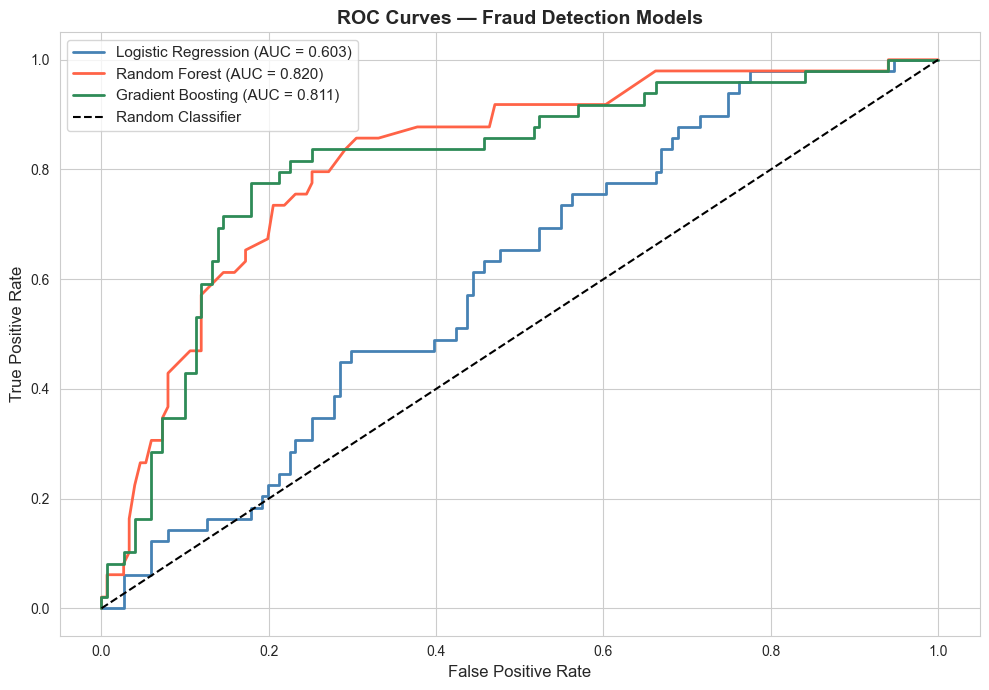

In [72]:
##ROC Curves for all models
fig, ax = mp.subplots(figsize=(10, 7))

colors = ['steelblue', 'tomato', 'seagreen']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(Y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})", color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Fraud Detection Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
mp.tight_layout()
mp.savefig('roc_curves.png', dpi=150)
mp.show()

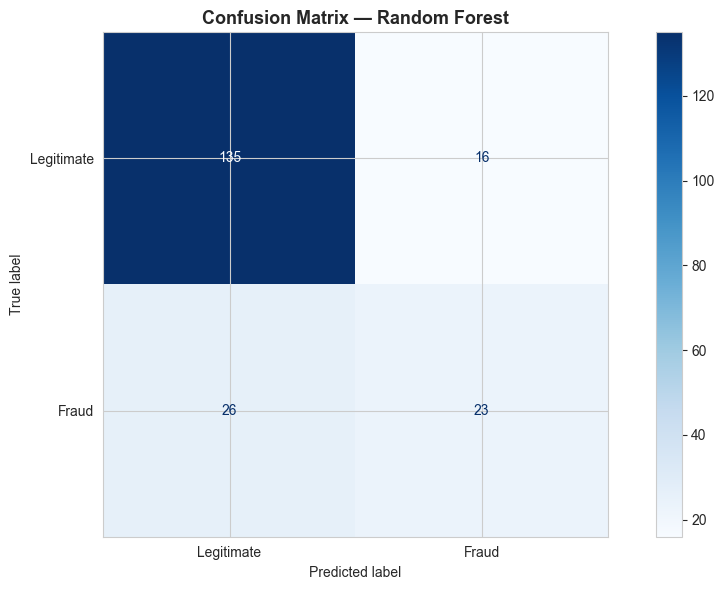

In [74]:
#Confusion Matrix for best model
best_name = max(results, key=lambda n: results[n]['auc'])
best = results[best_name]

cm = confusion_matrix(Y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Blues')
mp.title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
mp.tight_layout()
mp.savefig('confusion_matrix.png', dpi=150)
mp.show()

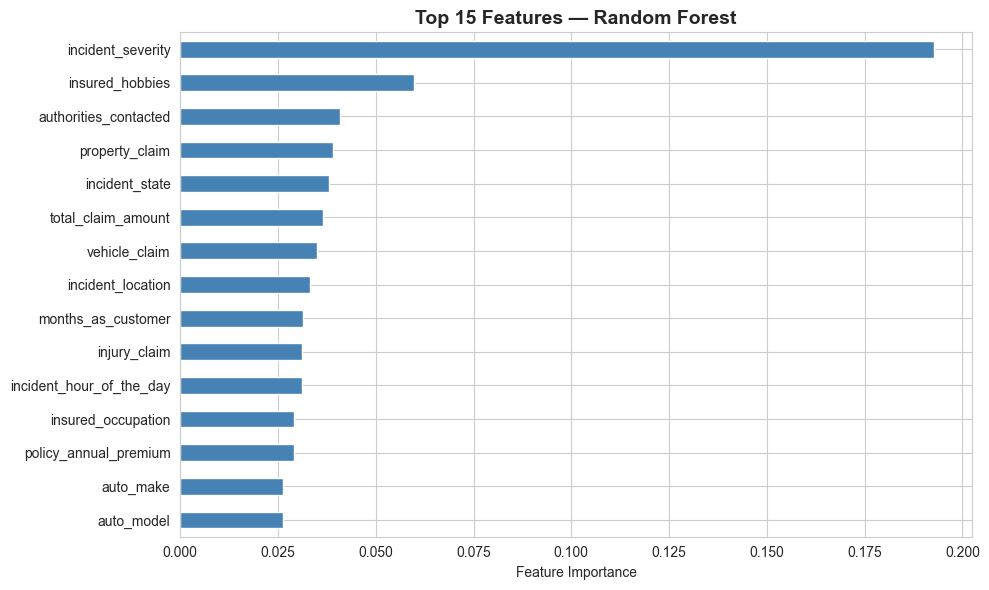

In [76]:
#Feature Importance (from Random Forest)
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

top15.sort_values().plot(kind='barh', color='steelblue')
mp.title('Top 15 Features — Random Forest', fontsize=14, fontweight='bold')
mp.xlabel('Feature Importance')
mp.tight_layout()
mp.savefig('feature_importance.png', dpi=150)
mp.show()